<a href="https://colab.research.google.com/github/davidlealo/practicos_sisrec_2026/blob/main/practico06/06_lightfm_respuesta.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Práctico de LightFM

## 1. Introducción

Este práctico contiene un ejemplo de uso de LightFM, usando correspondiente biblioteca. Además contiene ejemplos de algunas funciones útiles de la biblioteca `recommenders`, para visualización y evaluación de modelos

## 2. Recomendación de películas usando feedback explícito

### 2.1 Instalar e importar bibliotecas

In [1]:
!pip install git+https://github.com/daviddavo/lightfm

  Cloning https://github.com/daviddavo/lightfm to /tmp/pip-req-build-qjicjb50
  Running command git clone --filter=blob:none --quiet https://github.com/daviddavo/lightfm /tmp/pip-req-build-qjicjb50
  Resolved https://github.com/daviddavo/lightfm to commit f0eb500ead54ab65eb8e1b3890337a7223a35114
  Preparing metadata (setup.py) ... done
  Created wheel for lightfm: filename=lightfm-1.17-cp312-cp312-linux_x86_64.whl size=1100858 sha256=6d210fb48e0ffd9f669ff0bfa4bd3beb6472a42ebdc98894823e0b0bc0c46655
  Stored in directory: /tmp/pip-ephem-wheel-cache-eqg5ovbi/wheels/fd/89/93/70c1e5f378ee5043de89387ee3ef6852ff39e3b9eb44ecc1a3
Successfully built lightfm


In [2]:
!pip install recommenders

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 51.4/51.4 kB 3.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.4/154.4 kB 16.6 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.0/44.0 kB 4.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.2/46.2 kB 4.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 355.3/355.3 kB 25.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 85.9/85.9 kB 10.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 29.6/29.6 MB 15.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 81.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 386.9/386.9 kB 39.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.0/12.0 MB 140.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.1/2.1 MB 59.2 MB/s et

Si sale un error de Pandas, se debe reiniciar el entorno de ejecución

In [3]:
import os
import sys
import itertools
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import lightfm
from lightfm import LightFM
from lightfm.data import Dataset
from lightfm import cross_validation
from lightfm.evaluation import precision_at_k as lightfm_prec_at_k
from lightfm.evaluation import recall_at_k as lightfm_recall_at_k

from recommenders.evaluation.python_evaluation import precision_at_k, recall_at_k
from recommenders.utils.timer import Timer
from recommenders.datasets import movielens
from recommenders.models.lightfm.lightfm_utils import (
    track_model_metrics,
    prepare_test_df,
    prepare_all_predictions,
    compare_metric,
    similar_users,
    similar_items,
)
from recommenders.utils.notebook_utils import store_metadata

print("System version: {}".format(sys.version))
print("LightFM version: {}".format(lightfm.__version__))


System version: 3.12.13 (main, Mar  4 2026, 09:23:07) [GCC 11.4.0]
LightFM version: 1.17


/usr/local/lib/python3.12/dist-packages/pandera/_pandas_deprecated.py:154: FutureWarning: Importing pandas-specific classes and functions from the
top-level pandera module will be **removed in a future version of pandera**.
If you're using pandera to validate pandas objects, we highly recommend updating
your import:

```
# old import
import pandera as pa

# new import
import pandera.pandas as pa
```

If you're using pandera to validate objects from other compatible libraries
like pyspark or polars, see the supported libraries section of the documentation
for more information on how to import pandera:

https://pandera.readthedocs.io/en/stable/supported_libraries.html

To disable this warning, set the environment variable:

```
export DISABLE_PANDERA_IMPORT_WARNING=True
```

  warnings.warn(_future_warning, FutureWarning)


### 2.2 Hiperparámetros

En la siguiente celda se definen algunos hiperparámetros que se usarán a lo largo del práctico.

In [4]:
MOVIELENS_DATA_SIZE = '100k'    # Tamaño del dataset (se puede cambiar para recomendar con más datos)

K = 10                          # Tamaño de la recomendación
TEST_PERCENTAGE = 0.25          # Porcentaje usado para set de test
LEARNING_RATE = 0.25
LOSS_FUNCTION = 'bpr'
NO_COMPONENTS = 20              # Factores latentes
NO_EPOCHS = 20                  # Épocas para el entrenamiento
NO_THREADS = 32
ITEM_ALPHA = 1e-6               # Regularizaciones
USER_ALPHA = 1e-6

SEED = 42                       # Semilla para los splits de los datos (se puede eliminar si se desea experimentar)

### 2.2 Obtener dataset

En este práctico se usará el dataset de Movielens 100K.

In [5]:
data = movielens.load_pandas_df(
    size=MOVIELENS_DATA_SIZE,
    genres_col='genre',
    header=["userID", "itemID", "rating"]
)
data.sample(5, random_state=SEED)

100%|██████████| 4.81k/4.81k [00:00<00:00, 5.61kKB/s]


,userID,itemID,rating,genre
75721,877,381,4.0,Comedy|Romance
80184,815,602,3.0,Musical|Romance
19864,94,431,4.0,Action|Adventure
76699,416,875,2.0,Drama|Romance
92991,500,182,2.0,Crime|Drama


### 2.3 Preparar datos

Para poder entrenar el modelo LightFM, se debe crear una instancia del objeto `Dataset` de la misma biblioteca, para contener las interacciones entre usuarios e items.

In [6]:
dataset = Dataset()

Se usa el método `fit` para crear los mapeos correspondientes entre usuarios e items.

In [7]:
dataset.fit(users=data['userID'],
            items=data['itemID'])

# quick check to determine the number of unique users and items in the data
num_users, num_topics = dataset.interactions_shape()
print(f'Num users: {num_users}, num_topics: {num_topics}.')

Num users: 943, num_topics: 1682.


A partir de esto se puede crear las matrices de interacción y pesos mediante el método `build_interactions`.

In [8]:
(interactions, weights) = dataset.build_interactions(data.iloc[:, 0:3].values)

LightFM require que las matrices de interacciones sean del mismo tamaño, para lo cual provee el módulo `cross_validation`, que permite garantizar esto al generar una división aleatoria de los datos.

Nota: esta división no garantiza que los elementos del conjunto de test tengan interacciones previas en el conjunto de train. ¿A qué puede conllevar esto?

In [9]:
train_interactions, test_interactions = cross_validation.random_train_test_split(
    interactions, test_percentage=TEST_PERCENTAGE,
    random_state=np.random.RandomState(SEED))

In [10]:
print(f"Shape of train interactions: {train_interactions.shape}")
print(f"Shape of test interactions: {test_interactions.shape}")

Shape of train interactions: (943, 1682)
Shape of test interactions: (943, 1682)


### 2.4 Entrenar LightFM

Inicializamos el modelo con los hiperparámetros definidos arriba

In [11]:
model1 = LightFM(loss=LOSS_FUNCTION, no_components=NO_COMPONENTS,
                 learning_rate=LEARNING_RATE,
                 random_state=np.random.RandomState(SEED))

Entrenamos el modelo

In [12]:
model1.fit(interactions=train_interactions,
          epochs=NO_EPOCHS);

### 2.5 Preparar datos para evaluación

La biblioteca que se está usando requiere que los datos tengan un formato específico, para lo cual provee distintas funciones que realizan este trabajo.

Primero se obtienen los ids de usuarios, items y las interacciones

In [13]:
uids, iids, interaction_data = cross_validation._shuffle(
    interactions.row, interactions.col, interactions.data,
    random_state=np.random.RandomState(SEED))

cutoff = int((1.0 - TEST_PERCENTAGE) * len(uids))
test_idx = slice(cutoff, None)

Luego, se generan mapeos para relacionar los usuarios e items con sus representaciones

In [14]:
uid_map, ufeature_map, iid_map, ifeature_map = dataset.mapping()

A partir de esto se genera el *dataframe* de test

In [15]:
with Timer() as test_time:
    test_df = prepare_test_df(test_idx, uids, iids, uid_map, iid_map, weights)
print(f"Took {test_time.interval:.1f} seconds for prepare and predict test data.")
time_reco1 = test_time.interval

Took 1.5 seconds for prepare and predict test data.


In [16]:
test_df.sample(5, random_state=SEED)

,userID,itemID,rating
6868,293,657,4.0
24016,221,358,3.0
9668,587,875,1.0
13640,648,177,5.0
14018,343,89,3.0


Ahora, se genera el *dataframe* para todas las interacciones no vistas. Hacemos una predicción para todos los pares usuario-ítem, para los cuales no se tiene información (aquellos que no se encuentran en el conjunto de entrenamiento)

In [17]:
with Timer() as test_time:
    all_predictions = prepare_all_predictions(data, uid_map, iid_map,
                                              interactions=train_interactions,
                                              model=model1,
                                              num_threads=NO_THREADS)
print(f"Took {test_time.interval:.1f} seconds for prepare and predict all data.")
time_reco2 = test_time.interval

Took 1046.8 seconds for prepare and predict all data.


In [18]:
all_predictions.sample(5, random_state=SEED)

,userID,itemID,prediction
471550,321,773,-13.987448
373280,29,1493,-6.042176
1271323,798,1568,-18.470480
310738,281,725,-3.375966
1323612,833,370,-18.599344


¿Por qué las predicciones entregan números tan raros?

¿De qué podría servir una predicción así?

### 2.6 Evaluación

Una vez hecha las predicción, se evalúan los resultados mediante las medidas de Precision@K and Recall@K. Para esto se tiene como opción la implementación de la biblioteca `recommenders` y la implementación de `lightfm`.

In [19]:
with Timer() as test_time:
    eval_precision = precision_at_k(rating_true=test_df,
                                rating_pred=all_predictions, k=K)
    eval_recall = recall_at_k(test_df, all_predictions, k=K)
time_reco3 = test_time.interval

with Timer() as test_time:
    eval_precision_lfm = lightfm_prec_at_k(model1, test_interactions,
                                           train_interactions, k=K).mean()
    eval_recall_lfm = lightfm_recall_at_k(model1, test_interactions,
                                          train_interactions, k=K).mean()
time_lfm = test_time.interval

print(
    "------ Using Repo's evaluation methods ------",
    f"Precision@K:\t{eval_precision:.6f}",
    f"Recall@K:\t{eval_recall:.6f}",
    "\n------ Using LightFM evaluation methods ------",
    f"Precision@K:\t{eval_precision_lfm:.6f}",
    f"Recall@K:\t{eval_recall_lfm:.6f}",
    sep='\n')

------ Using Repo's evaluation methods ------
Precision@K:	0.178049
Recall@K:	0.097518

------ Using LightFM evaluation methods ------
Precision@K:	0.178049
Recall@K:	0.097518


## 3. Recomendación en base a feedback implícito

### 3.1 Extraer y preparar géneros de las películas

Usaremos los géneros de las películas como metadata de los items del conjunto de datos.

In [20]:
movie_genre = [x.split('|') for x in data['genre']]

Todos los géneros

In [21]:
all_movie_genre = sorted(list(set(itertools.chain.from_iterable(movie_genre))))
all_movie_genre

['Action',
 'Adventure',
 'Animation',
 "Children's",
 'Comedy',
 'Crime',
 'Documentary',
 'Drama',
 'Fantasy',
 'Film-Noir',
 'Horror',
 'Musical',
 'Mystery',
 'Romance',
 'Sci-Fi',
 'Thriller',
 'War',
 'Western',
 'unknown']

### 3.2 Obtener metadata de usuarios

Usaremos metadata de Movielens para obtener las ocupaciones de los usuarios.

#### 3.2.1 Juntar datos

In [22]:
user_feature_URL = 'http://files.grouplens.org/datasets/movielens/ml-100k/u.user'
columns = ['userID','age','gender','occupation','zipcode']
user_data = pd.read_table(user_feature_URL, sep='|', header=None, names=columns)

new_data = data.merge(user_data[['userID','occupation']], left_on='userID', right_on='userID')
new_data.sample(5, random_state=SEED)

,userID,itemID,rating,genre,occupation
75721,877,381,4.0,Comedy|Romance,other
80184,815,602,3.0,Musical|Romance,other
19864,94,431,4.0,Action|Adventure,student
76699,416,875,2.0,Drama|Romance,student
92991,500,182,2.0,Crime|Drama,administrator


#### 3.2.2 Todas las ocupaciones

In [23]:
all_occupations = sorted(list(set(new_data['occupation'])))

### 3.3 Prepare data and features

Repetimos la creación del objeto `Dataset`, pero agregamos características (*features*) para usuarios e items.

In [24]:
dataset2 = Dataset()
dataset2.fit(data['userID'],
            data['itemID'],
            item_features=all_movie_genre,
            user_features=all_occupations)

Creamos una matriz de características para items usando el método `build_item_features`

In [25]:
item_features = dataset2.build_item_features((x, y) for x,y in zip(data.itemID, movie_genre))

Y repetimos el proceso usando `build_user_features` para usuarios:

In [26]:
user_features = dataset2.build_user_features((x, [y]) for x,y in zip(new_data.userID, new_data['occupation']))

Repetimos el proceso de crear las matrices de interacción y pesos

In [27]:
interactions2, weights2 = dataset2.build_interactions(data.iloc[:, 0:3].values)

train_interactions2, test_interactions2 = cross_validation.random_train_test_split(
    interactions2,
    test_percentage=TEST_PERCENTAGE,
    random_state=np.random.RandomState(SEED)
)

### 3.3 Entrenar el modelo con datos adicionales

Entrenamos el nuevo modelo

In [28]:
model2 = LightFM(loss=LOSS_FUNCTION, no_components=NO_COMPONENTS,
                 learning_rate=LEARNING_RATE,
                 item_alpha=ITEM_ALPHA,
                 user_alpha=USER_ALPHA,
                 random_state=np.random.RandomState(SEED)
                )

In [29]:
model2.fit(interactions=train_interactions2,
           user_features=user_features,
           item_features=item_features,
           epochs=NO_EPOCHS
           )

### 3.4 Preparar datos para evaluación

Nuevamente tenemos que reorganizar los datos para poder usar las funciones de evaluación provistas

In [30]:
uids, iids, interaction_data = cross_validation._shuffle(
    interactions2.row,
    interactions2.col,
    interactions2.data,
    random_state=np.random.RandomState(SEED)
)

uid_map, ufeature_map, iid_map, ifeature_map = dataset2.mapping()

Preparamos el *dataframe* de test

In [31]:
with Timer() as test_time:
    test_df2 = prepare_test_df(test_idx, uids, iids, uid_map, iid_map, weights2)
print(f"Took {test_time.interval:.1f} seconds for prepare and predict test data.")

Took 1.2 seconds for prepare and predict test data.


Realizamos todas las predicciones

In [32]:
with Timer() as test_time:
    all_predictions2 = prepare_all_predictions(data, uid_map, iid_map,
                                              interactions=train_interactions2,
                                               user_features=user_features,
                                               item_features=item_features,
                                               model=model2,
                                               num_threads=NO_THREADS)

print(f"Took {test_time.interval:.1f} seconds for prepare and predict all data.")

Took 735.9 seconds for prepare and predict all data.


### 3.5 Evaluación y comparación

Comparamos las métricas anteriores con las métricas obtenidas en el nuevo modelo

In [33]:
eval_precision2 = precision_at_k(rating_true=test_df2,
                                rating_pred=all_predictions2, k=K)
eval_recall2 = recall_at_k(test_df2, all_predictions2, k=K)

print(
    "------ Using only explicit ratings ------",
    f"Precision@K:\t{eval_precision:.6f}",
    f"Recall@K:\t{eval_recall:.6f}",
    "\n------ Using both implicit and explicit ratings ------",
    f"Precision@K:\t{eval_precision2:.6f}",
    f"Recall@K:\t{eval_recall2:.6f}",
    sep='\n')

------ Using only explicit ratings ------
Precision@K:	0.178049
Recall@K:	0.097518

------ Using both implicit and explicit ratings ------
Precision@K:	0.044645
Recall@K:	0.013478


Como era de esperarse, tenemos mejores resultados al integrar el feedback implícito.

¿Existe algún caso en que no ocurra esto?

## 4. Bonus: Evaluar entrenamiento

Las siguientes celdas muestran cómo usar las funciones provistas para hacer seguimiento del entrenamiento de los distintos modelos

/usr/local/lib/python3.12/dist-packages/recommenders/models/lightfm/lightfm_utils.py:121: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  fitting_metrics.metric.replace(metric_keys, inplace=True)


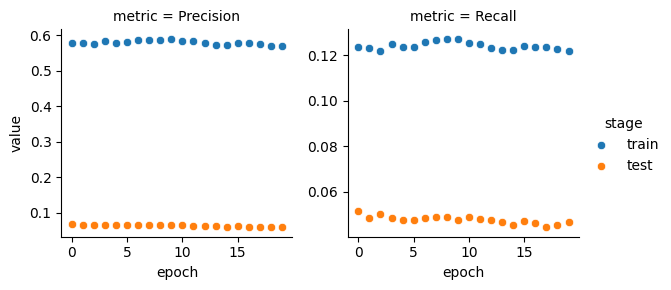

In [34]:
output1, _ = track_model_metrics(model=model1,
                                 train_interactions=train_interactions,
                                 test_interactions=test_interactions,
                                 k=K,
                                 no_epochs=NO_EPOCHS,
                                 no_threads=NO_THREADS)

/usr/local/lib/python3.12/dist-packages/recommenders/models/lightfm/lightfm_utils.py:121: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  fitting_metrics.metric.replace(metric_keys, inplace=True)


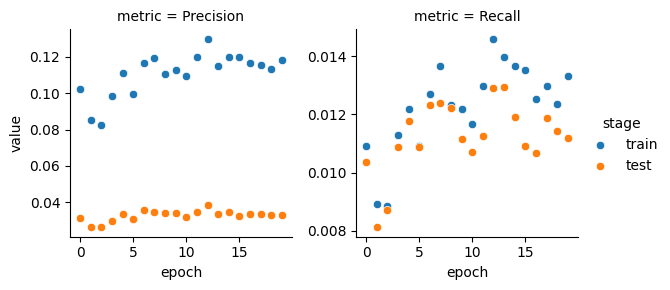

In [35]:
output2, _ = track_model_metrics(model=model2,
                                 train_interactions=train_interactions2,
                                 test_interactions=test_interactions2,
                                 k=K,
                                 no_epochs=NO_EPOCHS,
                                 no_threads=NO_THREADS,
                                 item_features=item_features,
                                 user_features=user_features)

### 4.1 Comparación de desempeño

Se generan visualizaciones para Precision y Recall

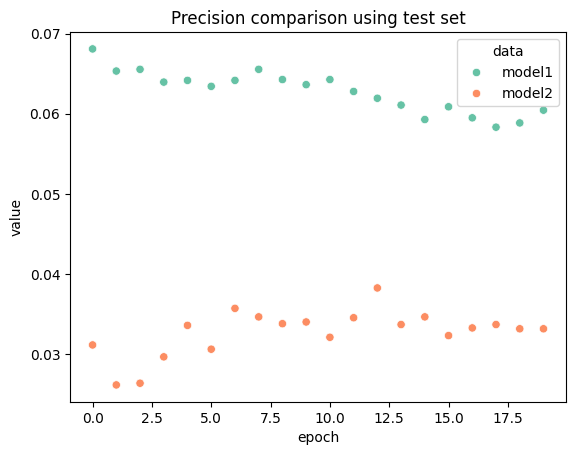

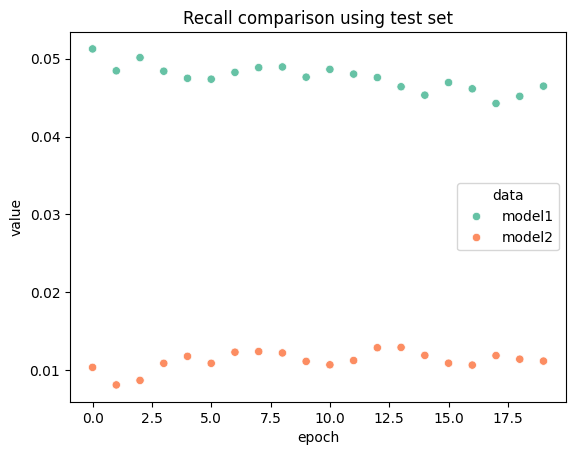

In [36]:
for i in ['Precision', 'Recall']:
    sns.set_palette("Set2")
    plt.figure()
    sns.scatterplot(x="epoch",
                    y="value",
                    hue='data',
                    data=compare_metric(df_list = [output1, output2], metric=i)
                   ).set_title(f'{i} comparison using test set');

¿Qué se puede concluir de estas imágenes?

## Actividad:

### Parte 1 (2ptos):

Explique de qué se trata el modelo LightFM.

*RESPUESTA:*

Es un modelo híbrido que que permite realizar recomendaciones combinando filtrado colaborativo con el filtrado basado en contenidos. Este modelo aprende de las caraterísticas y metadatos como suma de los factores latentes.

En el caso del notebook por ejemplo sumamos la ocupación a nuestro análisis de rating de la matriz de usuarios/item.

### Parte 2 (4ptos):

Elija uno de las dos versiones del problema de recomendación (con o sin información adicional para usuarios o ítems) e intente mejorar el desempeño de la recomendación. Para esto, pruebe al menos dos combinaciones de hiperparámetros distintas en el problema elegido. Se debe generar una hipótesis de por qué podría mejorar con dicha combinación de hiperparámetros.

PD: Se asignará puntaje completo tanto si se logra o no mejorar la recomendación. Lo importante es que hagan la experimentación.

In [37]:
#Primera prueba hiperparámetros
# Para esta prueba voy a cambiar la función de pérdida: https://making.lyst.com/lightfm/docs/examples/warp_loss.html

LEARNING_RATE = 0.25
LOSS_FUNCTION = 'warp'


In [38]:
model3 = LightFM(loss=LOSS_FUNCTION, no_components=NO_COMPONENTS,
                 learning_rate=LEARNING_RATE,
                 item_alpha=ITEM_ALPHA,
                 user_alpha=USER_ALPHA,
                 random_state=np.random.RandomState(SEED)
                )

In [39]:
model3.fit(interactions=train_interactions2,
           user_features=user_features,
           item_features=item_features,
           epochs=NO_EPOCHS
           )

In [40]:
uids, iids, interaction_data = cross_validation._shuffle(
    interactions2.row,
    interactions2.col,
    interactions2.data,
    random_state=np.random.RandomState(SEED)
)

uid_map, ufeature_map, iid_map, ifeature_map = dataset2.mapping()

In [41]:
with Timer() as test_time:
    test_df3 = prepare_test_df(test_idx, uids, iids, uid_map, iid_map, weights2)
print(f"Took {test_time.interval:.1f} seconds for prepare and predict test data.")

Took 1.1 seconds for prepare and predict test data.


In [42]:
with Timer() as test_time:
    all_predictions3 = prepare_all_predictions(data, uid_map, iid_map,
                                              interactions=train_interactions2,
                                               user_features=user_features,
                                               item_features=item_features,
                                               model=model3,
                                               num_threads=NO_THREADS)

print(f"Took {test_time.interval:.1f} seconds for prepare and predict all data.")

Took 738.8 seconds for prepare and predict all data.


In [43]:
eval_precision3 = precision_at_k(rating_true=test_df3,
                                rating_pred=all_predictions3, k=K)
eval_recall3 = recall_at_k(test_df3, all_predictions3, k=K)

print(
    "------ Using only explicit ratings ------",
    f"Precision@K:\t{eval_precision:.6f}",
    f"Recall@K:\t{eval_recall:.6f}",
    "\n------ Using both implicit and explicit ratings ------",
    f"Precision@K:\t{eval_precision2:.6f}",
    f"Recall@K:\t{eval_recall2:.6f}",
    "\n------ Using both implicit and explicit ratings: Cambio Loss Function ------",
    f"Precision@K:\t{eval_precision3:.6f}",
    f"Recall@K:\t{eval_recall3:.6f}",
    sep='\n'
)

------ Using only explicit ratings ------
Precision@K:	0.178049
Recall@K:	0.097518

------ Using both implicit and explicit ratings ------
Precision@K:	0.044645
Recall@K:	0.013478

------ Using both implicit and explicit ratings: Cambio Loss Function ------
Precision@K:	0.148887
Recall@K:	0.055627


/usr/local/lib/python3.12/dist-packages/recommenders/models/lightfm/lightfm_utils.py:121: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  fitting_metrics.metric.replace(metric_keys, inplace=True)


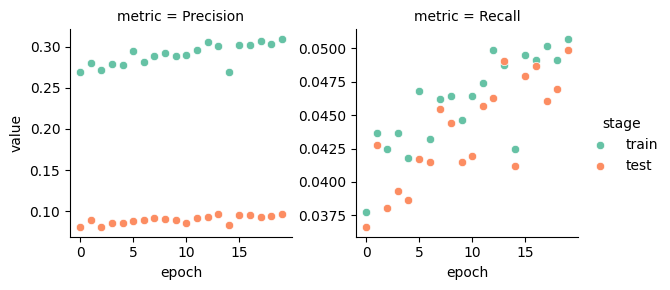

In [44]:
output3, _ = track_model_metrics(model=model3,
                                 train_interactions=train_interactions2,
                                 test_interactions=test_interactions2,
                                 k=K,
                                 no_epochs=NO_EPOCHS,
                                 no_threads=NO_THREADS,
                                 item_features=item_features,
                                 user_features=user_features)

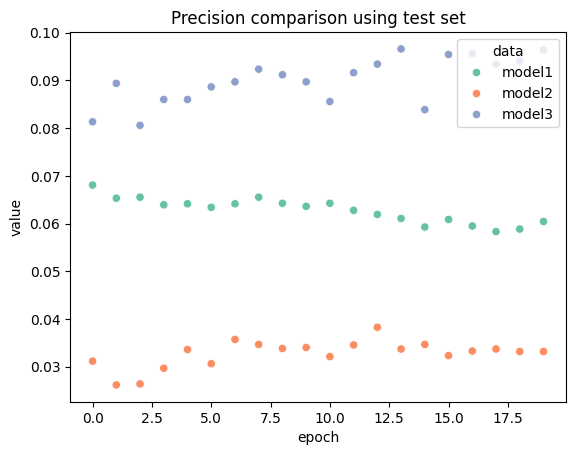

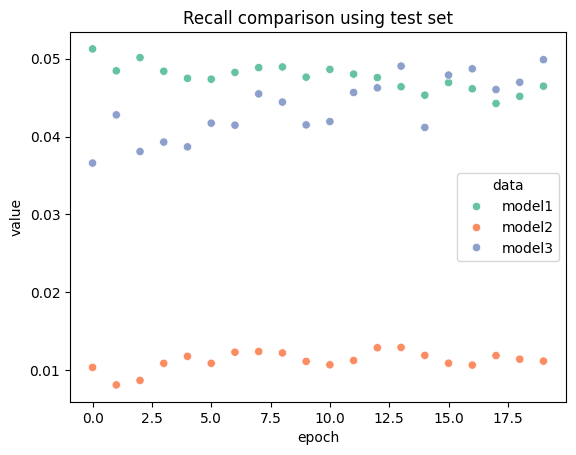

In [45]:
for i in ['Precision', 'Recall']:
    sns.set_palette("Set2")
    plt.figure()
    sns.scatterplot(x="epoch",
                    y="value",
                    hue='data',
                    data=compare_metric(df_list = [output1, output2, output3], metric=i)
                   ).set_title(f'{i} comparison using test set');

In [46]:
#Primera prueba hiperparámetros
# Para esta prueba voy a cambiar el learning rate

LEARNING_RATE = 0.1
LOSS_FUNCTION = 'warp'


In [47]:
model4 = LightFM(loss=LOSS_FUNCTION, no_components=NO_COMPONENTS,
                 learning_rate=LEARNING_RATE,
                 item_alpha=ITEM_ALPHA,
                 user_alpha=USER_ALPHA,
                 random_state=np.random.RandomState(SEED)
                )

In [48]:
model4.fit(interactions=train_interactions2,
           user_features=user_features,
           item_features=item_features,
           epochs=NO_EPOCHS
           )

In [49]:
uids, iids, interaction_data = cross_validation._shuffle(
    interactions2.row,
    interactions2.col,
    interactions2.data,
    random_state=np.random.RandomState(SEED)
)

uid_map, ufeature_map, iid_map, ifeature_map = dataset2.mapping()

In [50]:
with Timer() as test_time:
    test_df4 = prepare_test_df(test_idx, uids, iids, uid_map, iid_map, weights2)
print(f"Took {test_time.interval:.1f} seconds for prepare and predict test data.")

Took 1.2 seconds for prepare and predict test data.


In [51]:
with Timer() as test_time:
    all_predictions4 = prepare_all_predictions(data, uid_map, iid_map,
                                              interactions=train_interactions2,
                                               user_features=user_features,
                                               item_features=item_features,
                                               model=model4,
                                               num_threads=NO_THREADS)

print(f"Took {test_time.interval:.1f} seconds for prepare and predict all data.")

Took 740.7 seconds for prepare and predict all data.


In [52]:
eval_precision4 = precision_at_k(rating_true=test_df4,
                                rating_pred=all_predictions4, k=K)
eval_recall4 = recall_at_k(test_df4, all_predictions4, k=K)

print(
    "------ Using only explicit ratings ------",
    f"Precision@K:\t{eval_precision:.6f}",
    f"Recall@K:\t{eval_recall:.6f}",
    "\n------ Using both implicit and explicit ratings ------",
    f"Precision@K:\t{eval_precision2:.6f}",
    f"Recall@K:\t{eval_recall2:.6f}",
    "\n------ Using both implicit and explicit ratings: Cambio Loss Function ------",
    f"Precision@K:\t{eval_precision3:.6f}",
    f"Recall@K:\t{eval_recall3:.6f}",
    "\n------ Using both implicit and explicit ratings: Cambio Learning Rate ------",
    f"Precision@K:\t{eval_precision4:.6f}",
    f"Recall@K:\t{eval_recall4:.6f}",
    sep='\n'
)

------ Using only explicit ratings ------
Precision@K:	0.178049
Recall@K:	0.097518

------ Using both implicit and explicit ratings ------
Precision@K:	0.044645
Recall@K:	0.013478

------ Using both implicit and explicit ratings: Cambio Loss Function ------
Precision@K:	0.148887
Recall@K:	0.055627

------ Using both implicit and explicit ratings: Cambio Learning Rate ------
Precision@K:	0.130541
Recall@K:	0.042881


/usr/local/lib/python3.12/dist-packages/recommenders/models/lightfm/lightfm_utils.py:121: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  fitting_metrics.metric.replace(metric_keys, inplace=True)


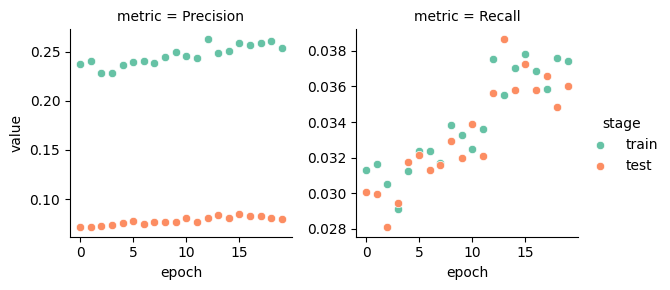

In [53]:
output4, _ = track_model_metrics(model=model4,
                                 train_interactions=train_interactions2,
                                 test_interactions=test_interactions2,
                                 k=K,
                                 no_epochs=NO_EPOCHS,
                                 no_threads=NO_THREADS,
                                 item_features=item_features,
                                 user_features=user_features)

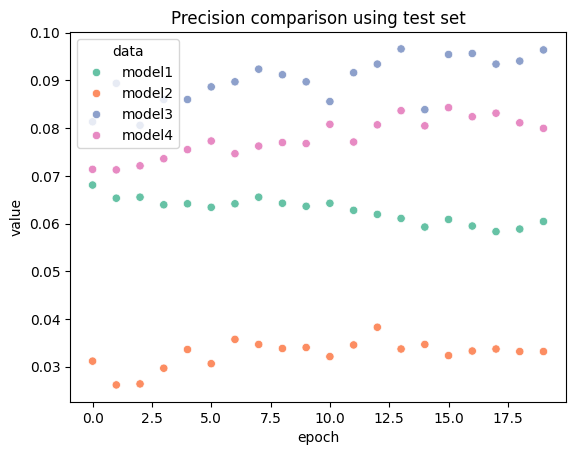

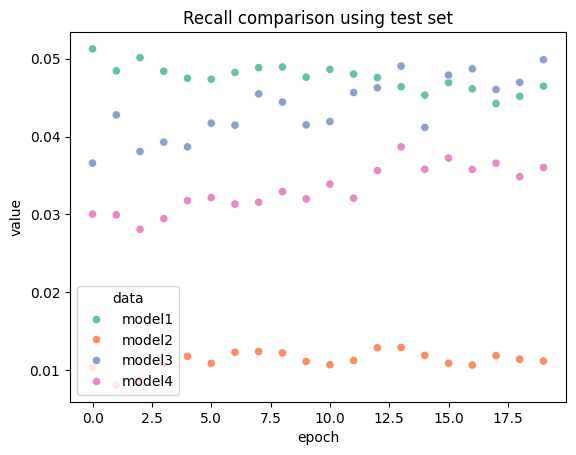

In [54]:
for i in ['Precision', 'Recall']:
    sns.set_palette("Set2")
    plt.figure()
    sns.scatterplot(x="epoch",
                    y="value",
                    hue='data',
                    data=compare_metric(df_list = [output1, output2, output3, output4], metric=i)
                   ).set_title(f'{i} comparison using test set');

In [55]:
user_feature_URL = 'http://files.grouplens.org/datasets/movielens/ml-100k/u.user'
columns = ['userID','age','gender','occupation','zipcode']
user_data = pd.read_table(user_feature_URL, sep='|', header=None, names=columns)

new_data_gender = data.merge(user_data[['userID','gender']], left_on='userID', right_on='userID')
new_data_gender.sample(5, random_state=SEED)

,userID,itemID,rating,genre,gender
75721,877,381,4.0,Comedy|Romance,M
80184,815,602,3.0,Musical|Romance,M
19864,94,431,4.0,Action|Adventure,M
76699,416,875,2.0,Drama|Romance,F
92991,500,182,2.0,Crime|Drama,M


In [56]:
all_genders = sorted(list(set(new_data_gender['gender'])))

In [57]:
dataset3 = Dataset()
dataset3.fit(data['userID'],
            data['itemID'],
            item_features=all_movie_genre,
            user_features=all_genders)

In [58]:
item_features = dataset3.build_item_features((x, y) for x,y in zip(data.itemID, movie_genre))

In [59]:
user_features = dataset3.build_user_features((x, [y]) for x,y in zip(new_data_gender.userID, new_data_gender['gender']))

In [60]:
interactions3, weights3 = dataset3.build_interactions(data.iloc[:, 0:3].values)

train_interactions3, test_interactions3 = cross_validation.random_train_test_split(
    interactions3,
    test_percentage=TEST_PERCENTAGE,
    random_state=np.random.RandomState(SEED)
)

In [61]:
model5 = LightFM(loss=LOSS_FUNCTION, no_components=NO_COMPONENTS,
                 learning_rate=LEARNING_RATE,
                 item_alpha=ITEM_ALPHA,
                 user_alpha=USER_ALPHA,
                 random_state=np.random.RandomState(SEED)
                )

In [62]:
model5.fit(interactions=train_interactions3,
           user_features=user_features,
           item_features=item_features,
           epochs=NO_EPOCHS
           )

In [63]:
uids, iids, interaction_data = cross_validation._shuffle(
    interactions3.row,
    interactions3.col,
    interactions3.data,
    random_state=np.random.RandomState(SEED)
)

uid_map, ufeature_map, iid_map, ifeature_map = dataset3.mapping()

In [64]:
with Timer() as test_time:
    test_df5 = prepare_test_df(test_idx, uids, iids, uid_map, iid_map, weights3)
print(f"Took {test_time.interval:.1f} seconds for prepare and predict test data.")

Took 1.2 seconds for prepare and predict test data.


In [65]:
with Timer() as test_time:
    all_predictions5 = prepare_all_predictions(data, uid_map, iid_map,
                                              interactions=train_interactions3,
                                               user_features=user_features,
                                               item_features=item_features,
                                               model=model3,
                                               num_threads=NO_THREADS)

print(f"Took {test_time.interval:.1f} seconds for prepare and predict all data.")

Took 744.8 seconds for prepare and predict all data.


In [66]:
eval_precision5 = precision_at_k(rating_true=test_df5,
                                rating_pred=all_predictions5, k=K)
eval_recall5 = recall_at_k(test_df5, all_predictions5, k=K)

print(
    "------ Using only explicit ratings ------",
    f"Precision@K:\t{eval_precision:.6f}",
    f"Recall@K:\t{eval_recall:.6f}",
    "\n------ Using both implicit and explicit ratings ------",
    f"Precision@K:\t{eval_precision2:.6f}",
    f"Recall@K:\t{eval_recall2:.6f}",
    "\n------ Using both implicit and explicit ratings: Cambio Loss Function ------",
    f"Precision@K:\t{eval_precision3:.6f}",
    f"Recall@K:\t{eval_recall3:.6f}",
    "\n------ Using both implicit and explicit ratings: Cambio Learning Rate ------",
    f"Precision@K:\t{eval_precision4:.6f}",
    f"Recall@K:\t{eval_recall4:.6f}",
    "\n------ Using both implicit and explicit ratings: Reemplazo de occupation por gender ------",
    f"Precision@K:\t{eval_precision5:.6f}",
    f"Recall@K:\t{eval_recall5:.6f}",
    sep='\n'
)

------ Using only explicit ratings ------
Precision@K:	0.178049
Recall@K:	0.097518

------ Using both implicit and explicit ratings ------
Precision@K:	0.044645
Recall@K:	0.013478

------ Using both implicit and explicit ratings: Cambio Loss Function ------
Precision@K:	0.148887
Recall@K:	0.055627

------ Using both implicit and explicit ratings: Cambio Learning Rate ------
Precision@K:	0.130541
Recall@K:	0.042881

------ Using both implicit and explicit ratings: Reemplazo de occupation por gender ------
Precision@K:	0.143054
Recall@K:	0.060537


/usr/local/lib/python3.12/dist-packages/recommenders/models/lightfm/lightfm_utils.py:121: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  fitting_metrics.metric.replace(metric_keys, inplace=True)


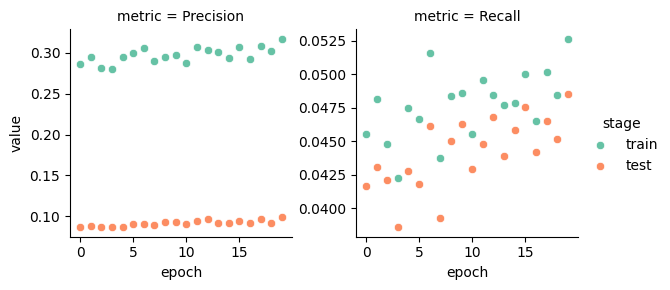

In [67]:
output5, _ = track_model_metrics(model=model5,
                                 train_interactions=train_interactions3,
                                 test_interactions=test_interactions3,
                                 k=K,
                                 no_epochs=NO_EPOCHS,
                                 no_threads=NO_THREADS,
                                 item_features=item_features,
                                 user_features=user_features)

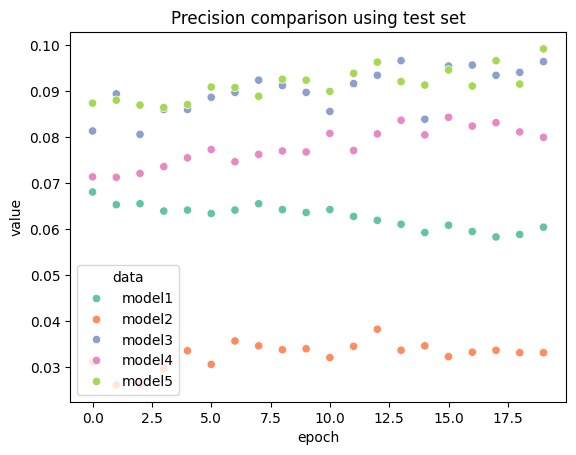

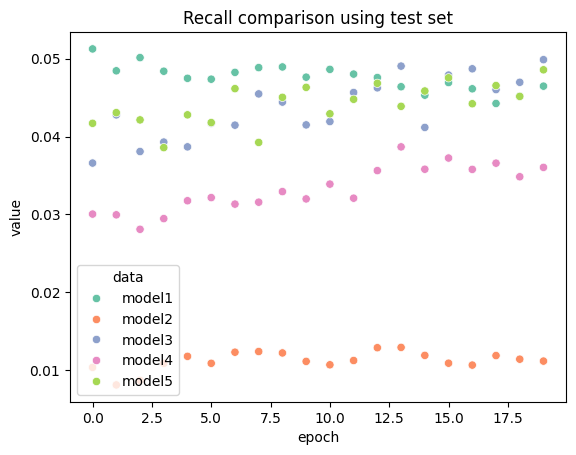

In [68]:
for i in ['Precision', 'Recall']:
    sns.set_palette("Set2")
    plt.figure()
    sns.scatterplot(x="epoch",
                    y="value",
                    hue='data',
                    data=compare_metric(df_list = [output1, output2, output3, output4, output5], metric=i)
                   ).set_title(f'{i} comparison using test set');

In [69]:
LEARNING_RATE = 0.3 #Prueba subiendo el learning rate

In [70]:
model6 = LightFM(loss=LOSS_FUNCTION, no_components=NO_COMPONENTS,
                 learning_rate=LEARNING_RATE,
                 item_alpha=ITEM_ALPHA,
                 user_alpha=USER_ALPHA,
                 random_state=np.random.RandomState(SEED)
                )

In [71]:
model6.fit(interactions=train_interactions3,
           user_features=user_features,
           item_features=item_features,
           epochs=NO_EPOCHS
           )

In [72]:
uids, iids, interaction_data = cross_validation._shuffle(
    interactions3.row,
    interactions3.col,
    interactions3.data,
    random_state=np.random.RandomState(SEED)
)

uid_map, ufeature_map, iid_map, ifeature_map = dataset3.mapping()

In [73]:
with Timer() as test_time:
    test_df6 = prepare_test_df(test_idx, uids, iids, uid_map, iid_map, weights3)
print(f"Took {test_time.interval:.1f} seconds for prepare and predict test data.")

Took 1.2 seconds for prepare and predict test data.


In [74]:
with Timer() as test_time:
    all_predictions6 = prepare_all_predictions(data, uid_map, iid_map,
                                              interactions=train_interactions3,
                                               user_features=user_features,
                                               item_features=item_features,
                                               model=model3,
                                               num_threads=NO_THREADS)

print(f"Took {test_time.interval:.1f} seconds for prepare and predict all data.")

Took 732.3 seconds for prepare and predict all data.


In [75]:
eval_precision6 = precision_at_k(rating_true=test_df6,
                                rating_pred=all_predictions6, k=K)
eval_recall6 = recall_at_k(test_df6, all_predictions6, k=K)

print(
    "------ Using only explicit ratings ------",
    f"Precision@K:\t{eval_precision:.6f}",
    f"Recall@K:\t{eval_recall:.6f}",
    "\n------ Using both implicit and explicit ratings ------",
    f"Precision@K:\t{eval_precision2:.6f}",
    f"Recall@K:\t{eval_recall2:.6f}",
    "\n------ Using both implicit and explicit ratings: Cambio Loss Function ------",
    f"Precision@K:\t{eval_precision3:.6f}",
    f"Recall@K:\t{eval_recall3:.6f}",
    "\n------ Using both implicit and explicit ratings: Cambio Learning Rate ------",
    f"Precision@K:\t{eval_precision4:.6f}",
    f"Recall@K:\t{eval_recall4:.6f}",
    "\n------ Using both implicit and explicit ratings: Reemplazo de occupation por gender ------",
    f"Precision@K:\t{eval_precision5:.6f}",
    f"Recall@K:\t{eval_recall5:.6f}",
    "\n------ Using both implicit and explicit ratings: Reemplazo de occupation por gender aumentando el LR ------",
    f"Precision@K:\t{eval_precision6:.6f}",
    f"Recall@K:\t{eval_recall6:.6f}",
    sep='\n'
)

------ Using only explicit ratings ------
Precision@K:	0.178049
Recall@K:	0.097518

------ Using both implicit and explicit ratings ------
Precision@K:	0.044645
Recall@K:	0.013478

------ Using both implicit and explicit ratings: Cambio Loss Function ------
Precision@K:	0.148887
Recall@K:	0.055627

------ Using both implicit and explicit ratings: Cambio Learning Rate ------
Precision@K:	0.130541
Recall@K:	0.042881

------ Using both implicit and explicit ratings: Reemplazo de occupation por gender ------
Precision@K:	0.143054
Recall@K:	0.060537

------ Using both implicit and explicit ratings: Reemplazo de occupation por gender aumentando el LR ------
Precision@K:	0.143054
Recall@K:	0.060537


/usr/local/lib/python3.12/dist-packages/recommenders/models/lightfm/lightfm_utils.py:121: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  fitting_metrics.metric.replace(metric_keys, inplace=True)


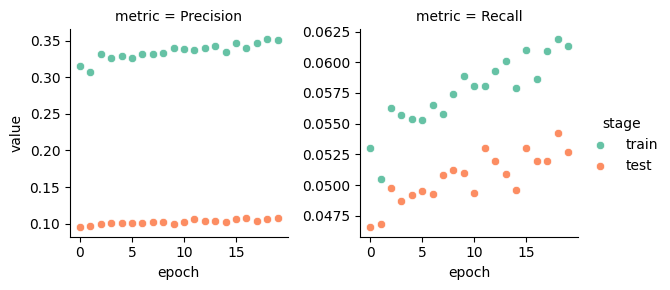

In [76]:
output6, _ = track_model_metrics(model=model6,
                                 train_interactions=train_interactions3,
                                 test_interactions=test_interactions3,
                                 k=K,
                                 no_epochs=NO_EPOCHS,
                                 no_threads=NO_THREADS,
                                 item_features=item_features,
                                 user_features=user_features)

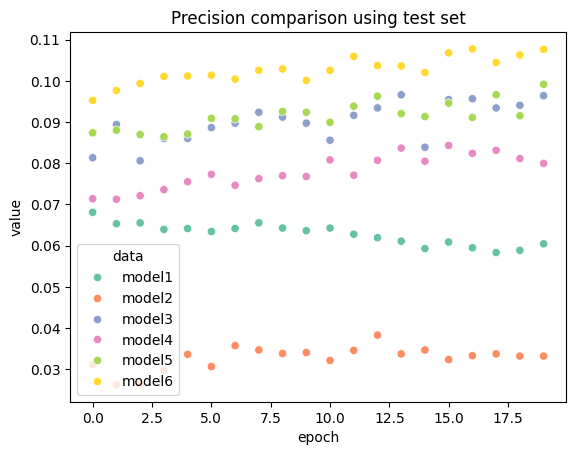

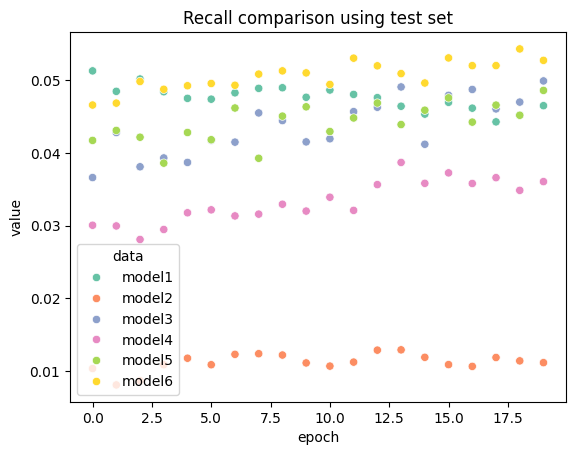

In [77]:
for i in ['Precision', 'Recall']:
    sns.set_palette("Set2")
    plt.figure()
    sns.scatterplot(x="epoch",
                    y="value",
                    hue='data',
                    data=compare_metric(df_list = [output1, output2, output3, output4, output5, output6], metric=i)
                   ).set_title(f'{i} comparison using test set');

### Resultados


Probé varias combinaciones. Lo primero es que a diferencia de lo que dice en el colab, al integrar las ocupaciones bajé en las métricas. Recuerdo que cuando lo vimos en la ayudantía dio el resultado alto y el bajo, todavía no entiendo eso.

De todas formas traté de hacer cambios para ganarle al primer modelo. Primero cambié la loss function de brp a warp. Por lo que leí a diferencia de brp que el negativo lo hace al azar, en warp busca el ítem negativo del aprendizaje que va obteniendo, que aunque también tiene el componente del azar busca competir con el ítem positivo generando mejor aprendizaje y en la misma documentación de LightFM dice que da mejor resultado (https://making.lyst.com/lightfm/docs/examples/warp_loss.html). Pero no fue suficiente.

Luego cambié el learning rate, tratando de que "los pasos" que da para el aprendizaje fueran más pequeños aprendiendo más en el camino y incluso empeoró un poco, así que todavía no le puedo ganar claramente al primer modelo, aunque se volvió completamente competitivo.

Luego cambié la ocupación por género, pensando que tal vez puede estar más relacionado con gustos (tal vez es aprendido y culpa de la sociedad, pero quería ver si podía mejorar la predicción) y ahí mejoró, especialente en el Recall@K. Aunque todavía quería hacer la prueba.

Ya lo tengo con gender y warp, pero al parecer bajar el learning rate en vez de hacer mejor aprendizaje no funcionó, entonces subí el learning rate a 0.3 y ahí superé al primer modelo.

Las razones al parecer tienen que ver con que warp es mejor para la predicción al generar la pérdida no solamente desde la búsqueda de valores al azar, sino mezclándolo con aprendizaje, que el learning rate mayor da mejor resultado en este modelo y que gender puede ser mejor para clasificar estos gustos.


Acá mi respuesta con la visualización antes de subir el trabajo: https://github.com/davidlealo/practicos_sisrec_2026/blob/main/practico06/06_lightfm_respuesta.ipynb